In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 1: Load Prepared Dataset

In [48]:
fitness_data = pd.read_excel("Fitness Classes Data/Cleaned_Preprocessed_Dataset_Yogeshwar Tribhuvan.xlsx")

### Step 2: Dataset Overview

In [49]:
fitness_data.head()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,1900-01-01 14:45:00,25,12,499
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,1900-01-01 14:45:00,25,15,499
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,1900-01-01 14:45:00,25,14,499
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,1900-01-01 14:45:00,25,9,499
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,1900-01-01 14:45:00,25,7,499


In [50]:
fitness_data.tail()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
3284,TSC,Zumba 6.30-7.30pm,2018-06-18,1900-01-01 18:30:00,18,9,1299
3285,TSC,Zumba 6.30-7.30pm,2018-06-25,1900-01-01 18:30:00,18,9,1299
3286,TSC,Zumba - 6-7pm,2018-06-07,1900-01-01 18:00:00,50,16,1299
3287,TSC,Zumba - 6-7pm,2018-06-14,1900-01-01 18:00:00,50,13,1299
3288,TSC,Zumba - 6-7pm,2018-06-21,1900-01-01 18:00:00,50,12,1299


In [79]:
fitness_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ActivitySiteID       3289 non-null   str           
 1   ActivityDescription  3289 non-null   str           
 2   BookingEndDate       3289 non-null   datetime64[us]
 3   BookingStartTime     3289 non-null   datetime64[us]
 4   MaxBookees           3289 non-null   int64         
 5   Number Booked        3289 non-null   int64         
 6   Price (INR)          3289 non-null   int64         
 7   Month                3289 non-null   str           
 8   Hour                 3289 non-null   int32         
 9   Session              3289 non-null   str           
 10  Booking_Rate         3289 non-null   float64       
dtypes: datetime64[us](2), float64(1), int32(1), int64(3), str(4)
memory usage: 385.1 KB


In [52]:
fitness_data.shape

(3289, 7)

In [53]:
fitness_data.describe()

,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
count,3289,3289,3289.000000,3289.000000,3289.000000
mean,2018-05-16 08:58:57.610215,1900-01-01 13:38:29.425358,32.179386,17.088781,1850.231377
min,2018-04-01 00:00:00,1900-01-01 06:30:00,2.000000,1.000000,499.000000
25%,2018-04-24 00:00:00,1900-01-01 10:00:00,24.000000,10.000000,1299.000000
50%,2018-05-16 00:00:00,1900-01-01 12:30:00,30.000000,16.000000,1499.000000
75%,2018-06-08 00:00:00,1900-01-01 17:45:00,35.000000,24.000000,2499.000000
max,2018-06-30 00:00:00,1900-01-01 20:15:00,70.000000,64.000000,3999.000000
std,NaN,NaN,15.092156,9.504098,791.207290


### Step 2: Basic Dataset Analysis

In [54]:
#Total Number of Activity Sites
fitness_data["ActivitySiteID"].nunique()

5

In [55]:
#Total Number of Fitness Activities
fitness_data["ActivityDescription"].nunique()

280

In [56]:
#List of Activity Sites
fitness_data["ActivitySiteID"].unique()


<ArrowStringArray>
['HXP', 'TSC', 'NBL', 'SBP', 'BRP']
Length: 5, dtype: str

In [57]:
#List of Fitness Activities
fitness_data["ActivityDescription"].unique()

<ArrowStringArray>
[  '20-20-20  2.45pm-3.45pm',      '20-20-20 7.00-8.00pm',
     '20-20-20 9.30-10.30am',        '20:20:20  10-11 Am',
   '20:20:20  10.00-11.00am',    '20:20:20  11am -12noon',
    '20:20:20  9.30-10.30am',     '20:20:20 9.30-10.30am',
   '45min Madness 9.15-10am',     '5.30-6.30pm Body Cond',
 ...
   'Studio Cyc 9.05 -9.55am',      'B L T Antenatal Mums',
         'B L T Chair Based',     'Body Cond 5.45-6.45pm',
       'Body Cond 1745-1845',   'Purestretch 6.45-7.45pm',
  'Family Bootcamp 4-4.45pm',     'Wm Better Living Team',
 'B L T- Weight Manage Clas', 'Strokeskill 19.15-20.15pm']
Length: 280, dtype: str

In [58]:
#Booking Date Range
fitness_data["BookingEndDate"].min()


Timestamp('2018-04-01 00:00:00')

In [59]:
fitness_data["BookingEndDate"].max()

Timestamp('2018-06-30 00:00:00')

In [60]:
#Total Classes Conducted
len(fitness_data)

3289

In [61]:
#Price Statistics
fitness_data["Price (INR)"].describe()

count    3289.000000
mean     1850.231377
std       791.207290
min       499.000000
25%      1299.000000
50%      1499.000000
75%      2499.000000
max      3999.000000
Name: Price (INR), dtype: float64

In [62]:
#Booking Statistics
fitness_data["Number Booked"].describe()

count    3289.000000
mean       17.088781
std         9.504098
min         1.000000
25%        10.000000
50%        16.000000
75%        24.000000
max        64.000000
Name: Number Booked, dtype: float64

In [63]:
fitness_data["Month"] = fitness_data["BookingEndDate"].dt.month_name()

In [64]:
fitness_data["Hour"] = fitness_data["BookingStartTime"].dt.hour

In [65]:
fitness_data["Session"] = fitness_data["Hour"].apply(
    lambda x:
    "Morning" if x < 12
    else "Afternoon" if x < 17
    else "Evening"
)

In [66]:
fitness_data["Booking_Rate"] = (
    fitness_data["Number Booked"] /
    fitness_data["MaxBookees"]
) * 100

In [67]:
fitness_data


,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Month,Hour,Session,Booking_Rate
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,1900-01-01 14:45:00,25,12,499,April,14,Afternoon,48.0
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,1900-01-01 14:45:00,25,15,499,April,14,Afternoon,60.0
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,1900-01-01 14:45:00,25,14,499,April,14,Afternoon,56.0
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,1900-01-01 14:45:00,25,9,499,April,14,Afternoon,36.0
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,1900-01-01 14:45:00,25,7,499,May,14,Afternoon,28.0
...,...,...,...,...,...,...,...,...,...,...,...
3284,TSC,Zumba 6.30-7.30pm,2018-06-18,1900-01-01 18:30:00,18,9,1299,June,18,Evening,50.0
3285,TSC,Zumba 6.30-7.30pm,2018-06-25,1900-01-01 18:30:00,18,9,1299,June,18,Evening,50.0
3286,TSC,Zumba - 6-7pm,2018-06-07,1900-01-01 18:00:00,50,16,1299,June,18,Evening,32.0
3287,TSC,Zumba - 6-7pm,2018-06-14,1900-01-01 18:00:00,50,13,1299,June,18,Evening,26.0


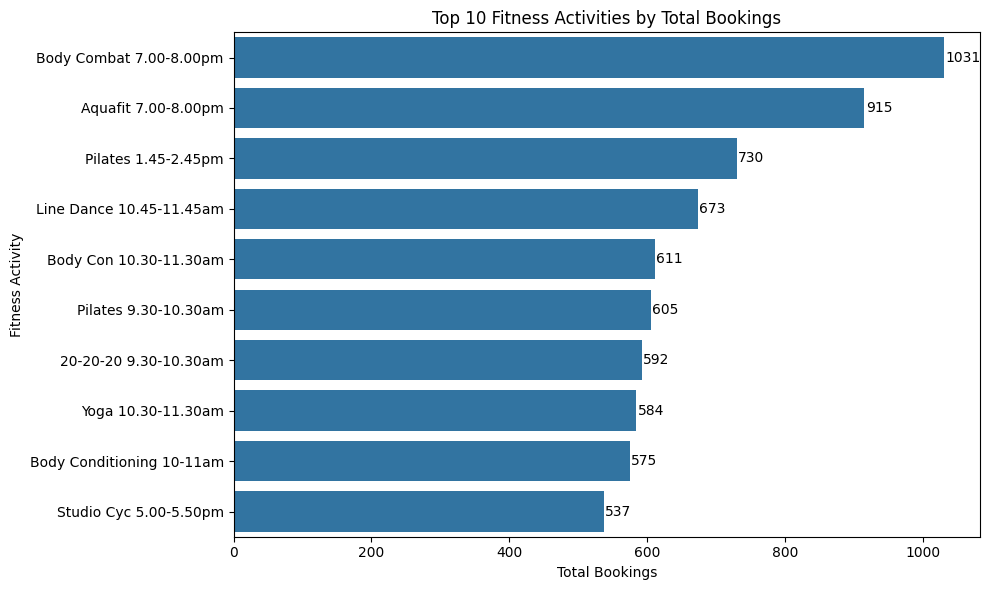

In [68]:
activity_bookings = (
    fitness_data.groupby("ActivityDescription")["Number Booked"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=activity_bookings.values,
    y=activity_bookings.index
)

# Add data labels
for i in ax.containers:
    ax.bar_label(i, fmt='%d', padding=1)

plt.title("Top 10 Fitness Activities by Total Bookings")
plt.xlabel("Total Bookings")
plt.ylabel("Fitness Activity")

plt.tight_layout()
plt.show()

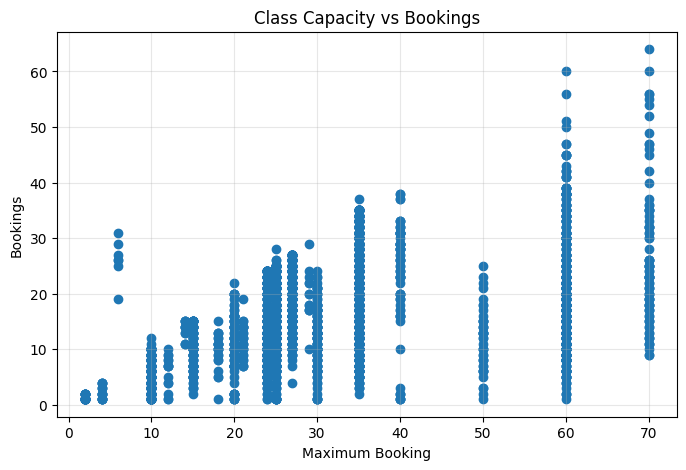

In [69]:
plt.figure(figsize=(8,5))

plt.scatter(
    fitness_data["MaxBookees"],

    fitness_data["Number Booked"]
)

plt.title("Class Capacity vs Bookings")
plt.xlabel("Maximum Booking")
plt.ylabel("Bookings")

plt.grid(alpha=0.3)

plt.show()

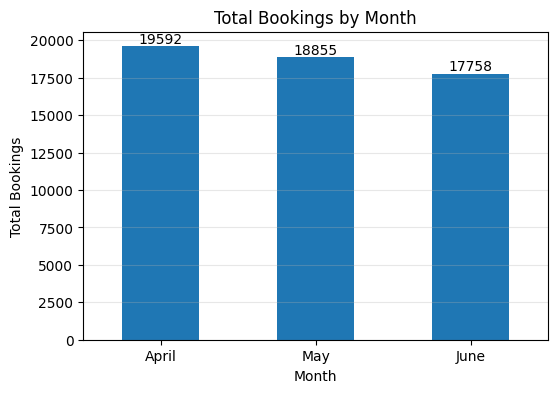

In [70]:
month_order = ["April", "May", "June"]

month_booking = (
    fitness_data.groupby("Month")["Number Booked"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(6,4))

ax = month_booking.plot(kind="bar")

plt.title("Total Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Total Bookings")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

# Data Labels
for i, value in enumerate(month_booking):
    ax.text(i, value, str(int(value)),
            ha='center', va='bottom', fontsize=10)

plt.show()

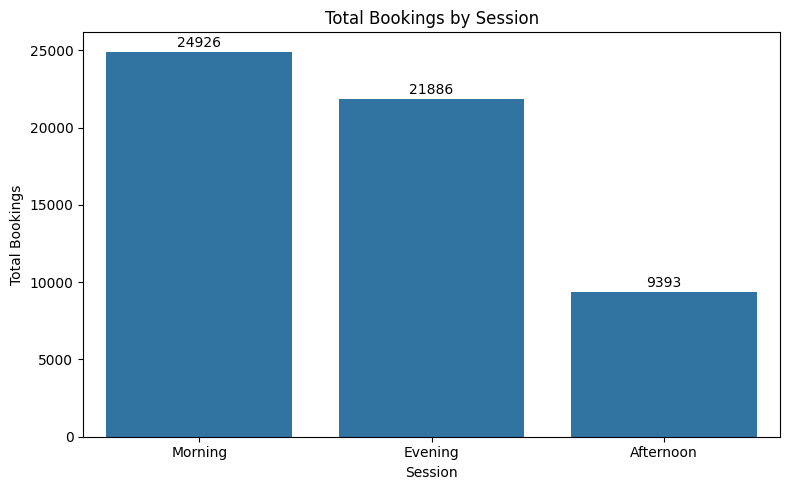

In [71]:
site_bookings = (
    fitness_data.groupby("Session")["Number Booked"]
    .sum()
    .sort_values(ascending=False)
  
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    
    x=site_bookings.index,
    y=site_bookings.values,
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1)

plt.title("Total Bookings by Session")
plt.xlabel("Session")
plt.ylabel("Total Bookings")

plt.tight_layout()
plt.show()


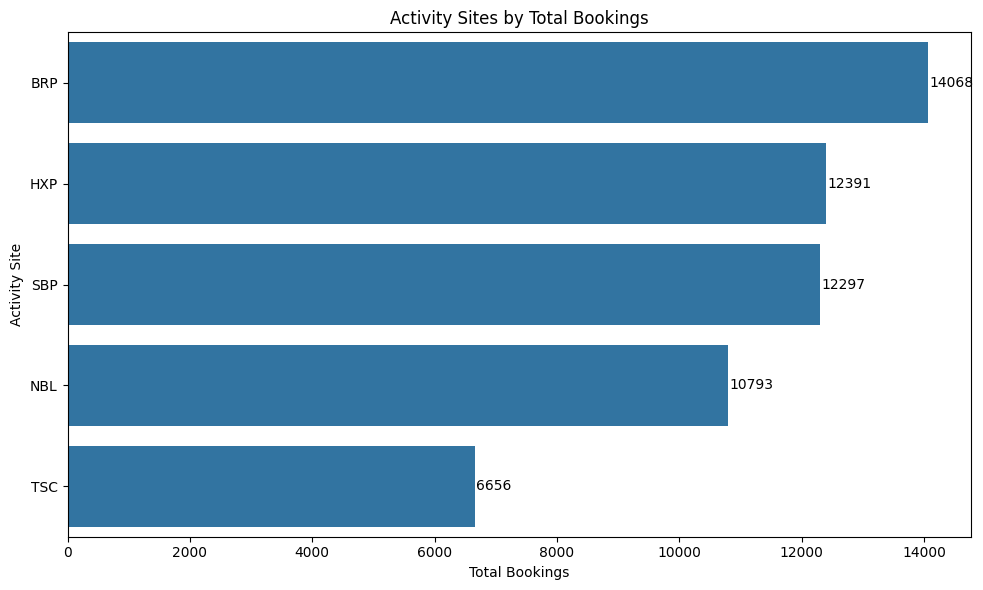

In [72]:
site_bookings = (
    fitness_data.groupby("ActivitySiteID")["Number Booked"]
    .sum()
    .sort_values(ascending=False)
  
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=site_bookings.values,
    y=site_bookings.index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1)

plt.title("Activity Sites by Total Bookings")
plt.xlabel("Total Bookings")
plt.ylabel("Activity Site")

plt.tight_layout()
plt.show()

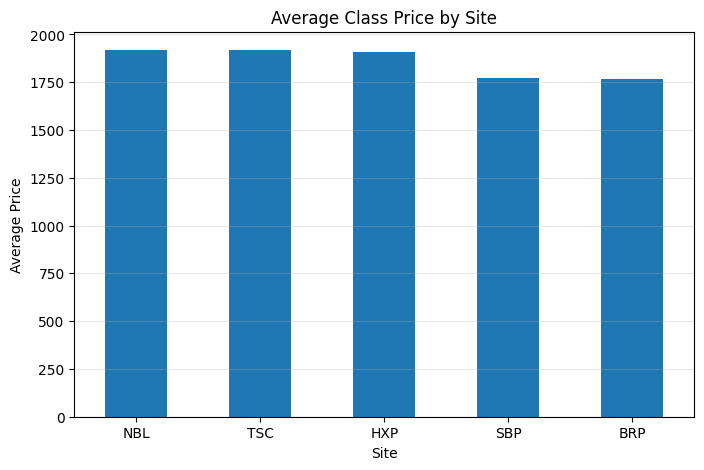

In [73]:
avg_price = (
    fitness_data
    .groupby("ActivitySiteID")["Price (INR)"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average Class Price by Site")
plt.xlabel("Site")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

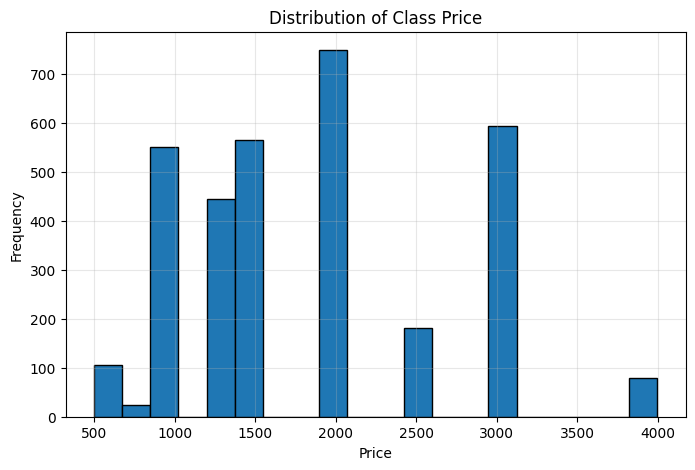

In [74]:
plt.figure(figsize=(8,5))

plt.hist(fitness_data["Price (INR)"], bins=20, edgecolor="black")

plt.title("Distribution of Class Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

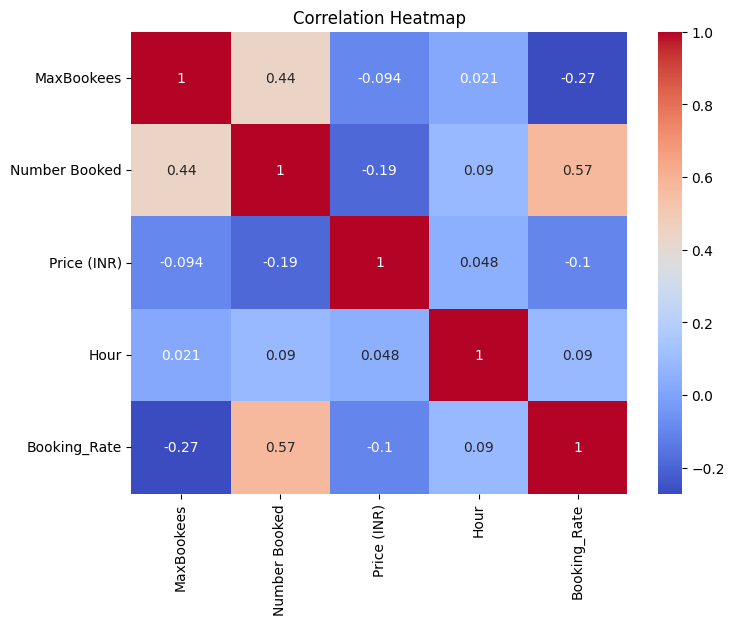

In [75]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    fitness_data.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()